# Сверточные нейронные сети (ноутбук)

> Знакомимся со сверточными нейронными сетями. Учимся решать задачу классификации изображений.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from time import perf_counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm import tqdm

warnings.filterwarnings('ignore')

plt.rc('font', size=30)

## Opencv
Библиотека для удобной работы с картинками

## Загрузка изображения

Загрузим изображение из интернета, например, мем про глубинное обучение.

In [ ]:
! wget "***" -O meme.png

## Чтение изображения

In [2]:
img = Image.open('meme.png')

In [3]:
img.format

'PNG'

In [4]:
img.size

(1024, 931)

In [5]:
img.mode

'P'

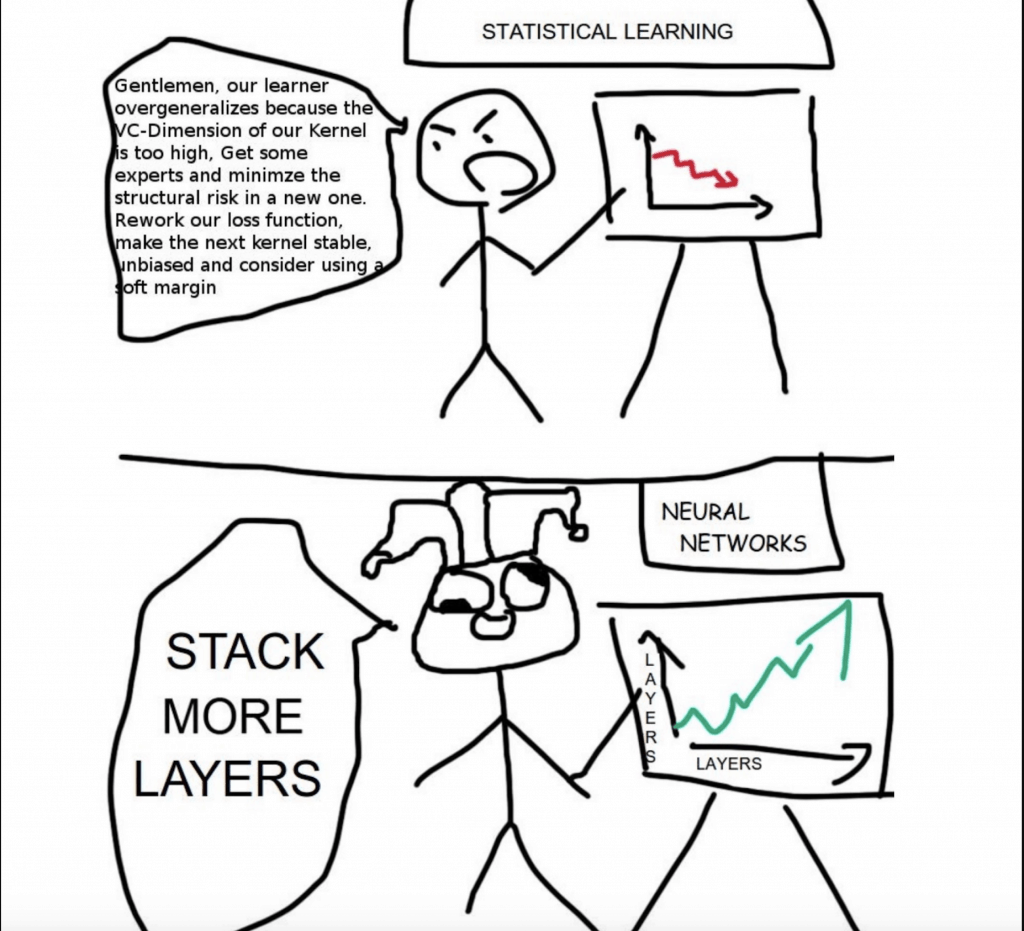

In [6]:
img

## Матричное представление

In [15]:
img_matrix = np.array(img.convert('RGB'))

In [16]:
img_matrix.shape

(931, 1024, 3)

In [18]:
img_matrix

array([[[ 13,  13,  13],
        [229, 229, 229],
        [255, 255, 255],
        ...,
        [203, 204, 204],
        [ 14,  14,  14],
        [ 14,  14,  14]],

       [[ 14,  14,  14],
        [229, 229, 229],
        [255, 255, 255],
        ...,
        [203, 204, 204],
        [ 14,  14,  14],
        [ 13,  13,  13]],

       [[ 13,  13,  13],
        [229, 229, 229],
        [255, 255, 255],
        ...,
        [203, 204, 204],
        [ 14,  14,  14],
        [ 14,  14,  14]],

       ...,

       [[ 13,  13,  13],
        [220, 220, 220],
        [244, 244, 244],
        ...,
        [195, 195, 196],
        [ 13,  13,  13],
        [ 13,  13,  13]],

       [[ 13,  13,  13],
        [220, 220, 220],
        [244, 244, 244],
        ...,
        [195, 195, 196],
        [ 12,  12,  12],
        [ 13,  13,  13]],

       [[ 13,  13,  13],
        [219, 218, 218],
        [244, 244, 244],
        ...,
        [195, 195, 196],
        [ 13,  13,  13],
        [ 13,  13,  13]]

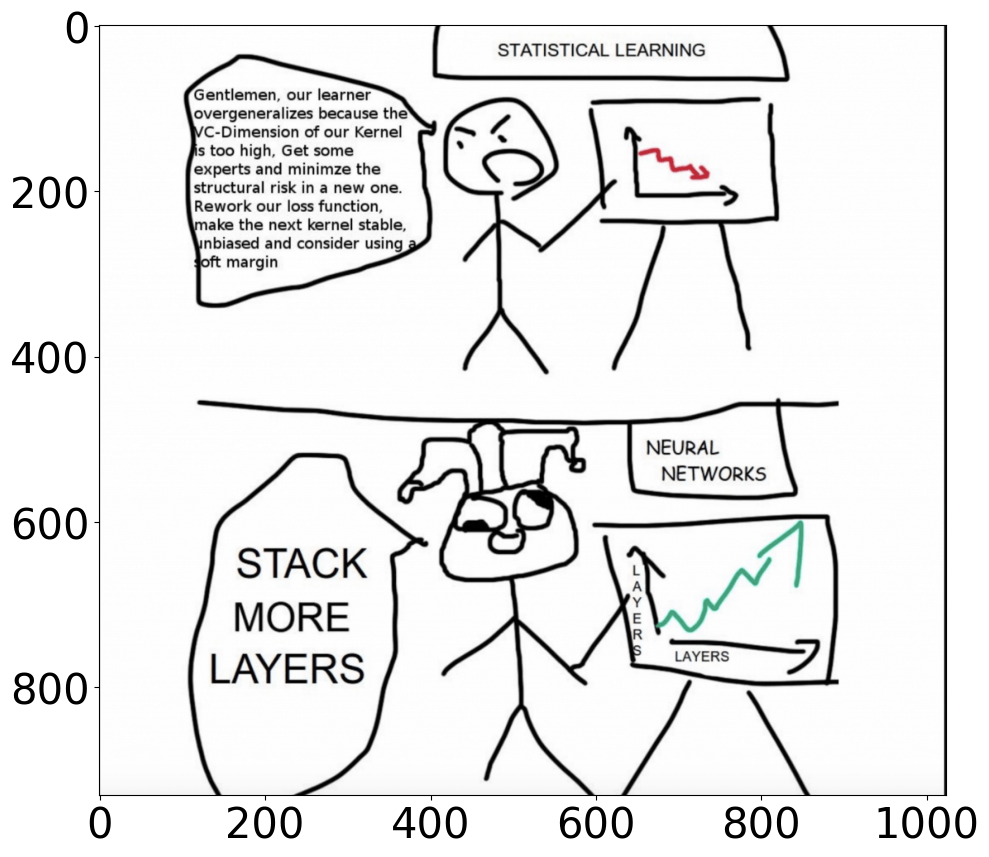

In [17]:
plt.figure(figsize=(20, 10))

plt.imshow(img_matrix)

plt.show()

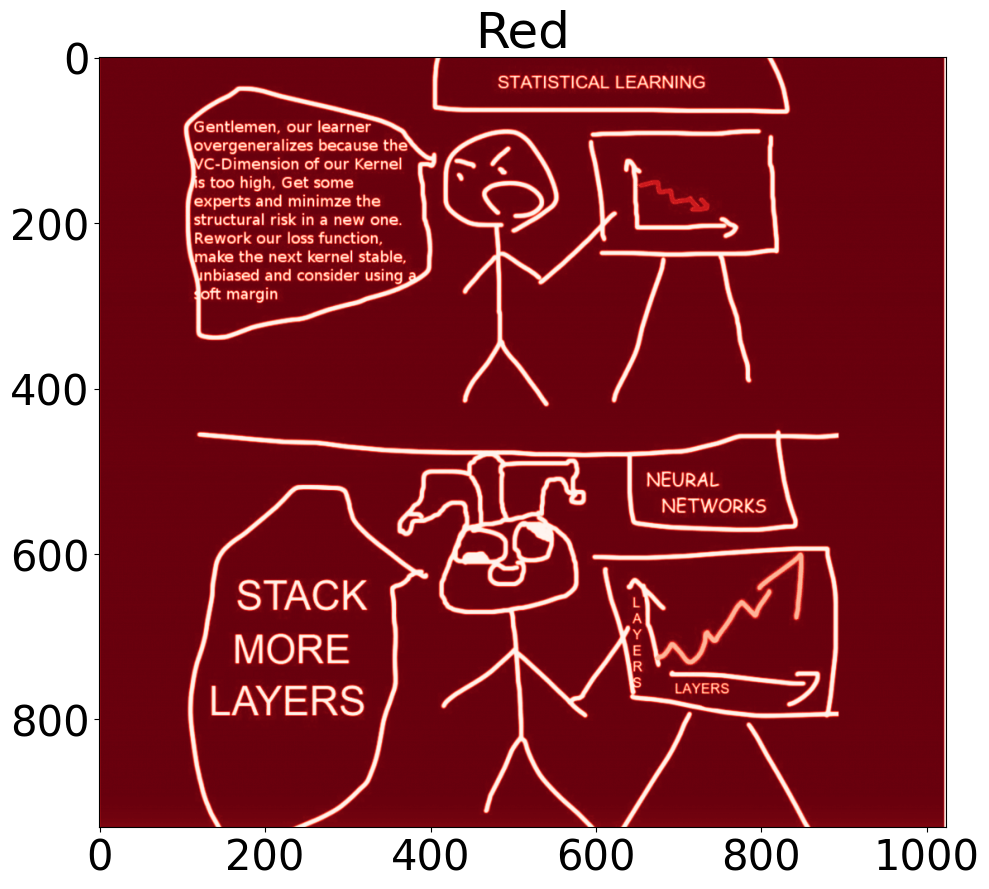

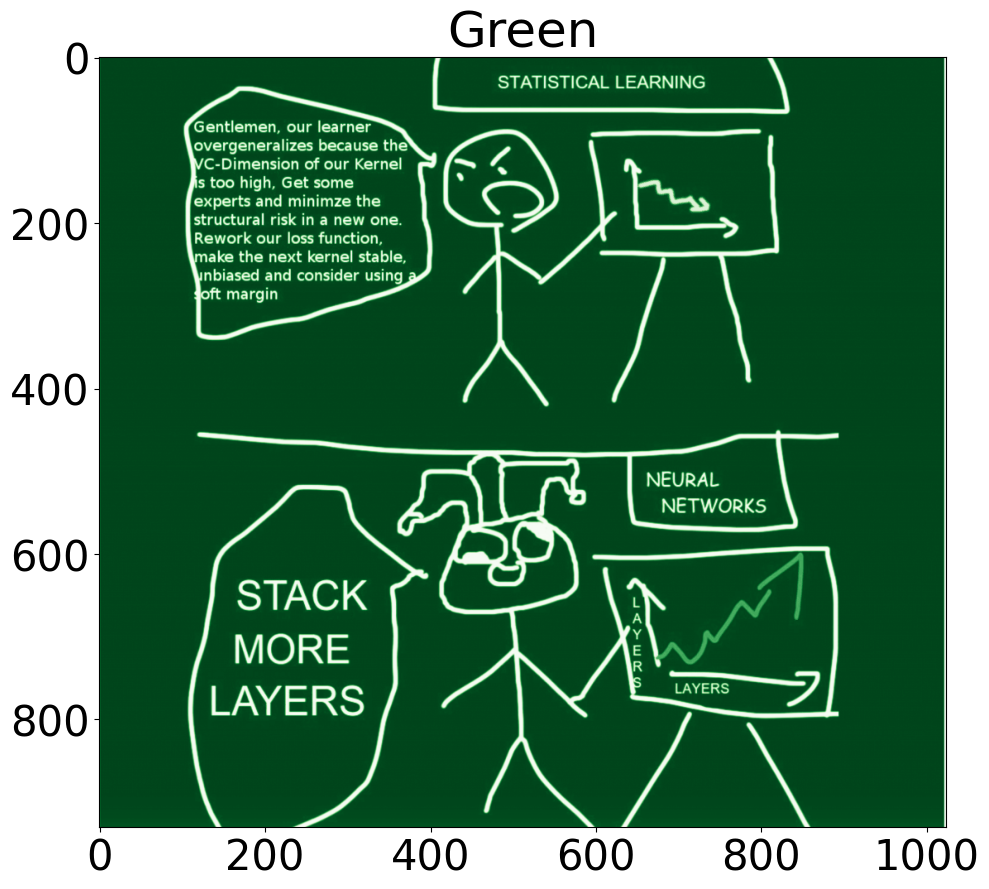

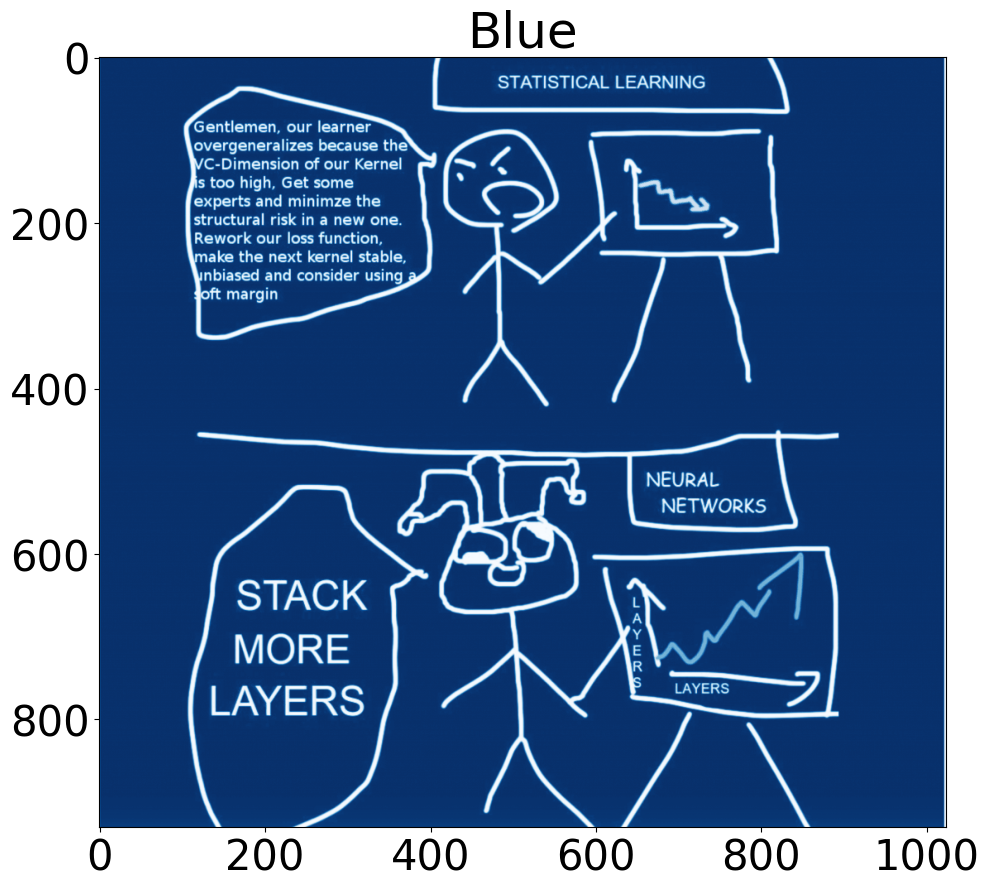

In [19]:
for i, (cmap, color) in enumerate(
    zip(
        [cm.Reds, cm.Greens, cm.Blues],
        ['Red', 'Green', 'Blue']
    )
):
    plt.figure(figsize=(20, 10))
    plt.imshow(img_matrix[:, :, i], cmap=cmap)
    plt.title(color)
    plt.show()

In [20]:
img_matrix[:, :, 0].min(), img_matrix[:, :, 0].max()

(0, 255)

In [21]:
img_matrix

array([[[ 13,  13,  13],
        [229, 229, 229],
        [255, 255, 255],
        ...,
        [203, 204, 204],
        [ 14,  14,  14],
        [ 14,  14,  14]],

       [[ 14,  14,  14],
        [229, 229, 229],
        [255, 255, 255],
        ...,
        [203, 204, 204],
        [ 14,  14,  14],
        [ 13,  13,  13]],

       [[ 13,  13,  13],
        [229, 229, 229],
        [255, 255, 255],
        ...,
        [203, 204, 204],
        [ 14,  14,  14],
        [ 14,  14,  14]],

       ...,

       [[ 13,  13,  13],
        [220, 220, 220],
        [244, 244, 244],
        ...,
        [195, 195, 196],
        [ 13,  13,  13],
        [ 13,  13,  13]],

       [[ 13,  13,  13],
        [220, 220, 220],
        [244, 244, 244],
        ...,
        [195, 195, 196],
        [ 12,  12,  12],
        [ 13,  13,  13]],

       [[ 13,  13,  13],
        [219, 218, 218],
        [244, 244, 244],
        ...,
        [195, 195, 196],
        [ 13,  13,  13],
        [ 13,  13,  13]]

## Свертка

Свертка в `PyTorch` представлена модулем `nn.Conv2d` со следующими параметрами:

- in_channels (int) – Количество каналов во входном изображении

- out_channels (int) – Количество каналов в выходном изображении

- kernel_size (int or tuple) – Размер ядра свертки

- stride (int or tuple, optional) – Страйд (шаг ядра свертки). По умолчанию: 1

- padding (int, tuple or str, optional) – Размер паддинга. По умолчанию: 0

- padding_mode (string, optional) – 'zeros', 'reflect', 'replicate' or 'circular'. По умолчанию: 'zeros'

- dilation (int or tuple, optional) – Дилейшн (шаг между элементами внутри ядра). По умолчанию: 1

- bias (bool, optional) – добавлять ли обучаемый сдвиг. По умолчанию: True

In [22]:
conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3
)

In [23]:
conv1.weight

Parameter containing:
tensor([[[[-0.0360, -0.1521, -0.0498],
          [ 0.0426,  0.0575, -0.1624],
          [-0.0254,  0.1338,  0.1526]],

         [[ 0.0488,  0.1607,  0.0580],
          [ 0.0124,  0.0878,  0.1676],
          [-0.1484,  0.0532, -0.0680]],

         [[ 0.0566,  0.1771,  0.1273],
          [-0.1914, -0.1392, -0.1401],
          [ 0.1136,  0.0589, -0.1582]]],


        [[[-0.0098, -0.0226,  0.0265],
          [ 0.0740, -0.0108,  0.0549],
          [-0.1113, -0.1326, -0.0310]],

         [[ 0.0219,  0.0337, -0.0812],
          [-0.0829,  0.1560,  0.1849],
          [-0.1286, -0.1171,  0.1794]],

         [[-0.1365, -0.1870,  0.1467],
          [-0.1050, -0.1374, -0.0931],
          [-0.0355,  0.0921, -0.0555]]],


        [[[-0.0767, -0.1072, -0.1638],
          [ 0.0907,  0.1278, -0.1436],
          [ 0.0030, -0.0496,  0.0617]],

         [[-0.1104,  0.1804, -0.0783],
          [ 0.1546, -0.1570,  0.0717],
          [ 0.0939,  0.0651,  0.0134]],

         [[ 0.0161, -0

In [29]:
img_tensor = T.ToTensor()(img.convert('RGB')).unsqueeze(0)

In [30]:
img_tensor.shape

torch.Size([1, 3, 931, 1024])

In [31]:
output = conv1(img_tensor)

In [32]:
output.shape

torch.Size([1, 10, 929, 1022])

In [33]:
conv2 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    padding=1
)

In [34]:
output = conv2(img_tensor)

In [35]:
output.shape

torch.Size([1, 10, 931, 1024])

In [36]:
conv2(output)

RuntimeError: Given groups=1, weight of size [10, 3, 3, 3], expected input[1, 10, 931, 1024] to have 3 channels, but got 10 channels instead

## Пулинг

Пулинг представлен в модуле `torch.nn`, в основном будем использовать `MaxPool2d` и `AvgPool2d`.

Параметры:

- kernel_size – размер окошка

- stride – страйд окошка. По умолчанию равен kernel_size

- padding – сколько нулевого паддинга добавлять по краям. По умолчанию: 0.

In [37]:
img_tensor = torch.randint(0, 10, size=(10, 10), dtype=torch.float32).unsqueeze(0)

In [38]:
img_tensor

tensor([[[3., 2., 8., 4., 6., 2., 5., 5., 4., 6.],
         [3., 7., 9., 3., 5., 2., 8., 2., 1., 8.],
         [8., 0., 7., 5., 3., 2., 2., 5., 8., 7.],
         [0., 3., 2., 0., 9., 8., 5., 6., 6., 4.],
         [4., 1., 8., 8., 7., 7., 4., 6., 1., 7.],
         [3., 0., 2., 2., 4., 2., 6., 3., 6., 7.],
         [6., 5., 6., 1., 8., 8., 4., 4., 6., 9.],
         [6., 7., 7., 7., 5., 6., 8., 1., 7., 1.],
         [5., 8., 1., 0., 2., 4., 0., 4., 2., 5.],
         [6., 0., 8., 9., 4., 0., 5., 1., 5., 8.]]])

In [39]:
img_tensor.shape

torch.Size([1, 10, 10])

In [57]:
pooling1 = nn.MaxPool2d(kernel_size=2, stride=1)

In [63]:
pooling1(img_tensor)

tensor([[[7., 9., 9., 6., 6., 8., 8., 5., 8.],
         [8., 9., 9., 5., 5., 8., 8., 8., 8.],
         [8., 7., 7., 9., 9., 8., 6., 8., 8.],
         [4., 8., 8., 9., 9., 8., 6., 6., 7.],
         [4., 8., 8., 8., 7., 7., 6., 6., 7.],
         [6., 6., 6., 8., 8., 8., 6., 6., 9.],
         [7., 7., 7., 8., 8., 8., 8., 7., 9.],
         [8., 8., 7., 7., 6., 8., 8., 7., 7.],
         [8., 8., 9., 9., 4., 5., 5., 5., 8.]]])

In [64]:
pooling2 = nn.AvgPool2d(kernel_size=2)

In [65]:
pooling2(img_tensor)

tensor([[[3.7500, 6.0000, 3.7500, 5.0000, 4.7500],
         [2.7500, 3.5000, 5.5000, 4.5000, 6.2500],
         [2.0000, 5.0000, 5.0000, 4.7500, 5.2500],
         [6.0000, 5.2500, 6.7500, 4.2500, 5.7500],
         [4.7500, 4.5000, 2.5000, 2.5000, 5.0000]]])

## Датасет MNIST

In [66]:
mnist_train = MNIST(
    "../../datasets/mnist",
    train=False,
    download=True

)

100%|████████████████████████████████| 9.91M/9.91M [00:02<00:00, 3.67MB/s]
100%|█████████████████████████████████| 28.9k/28.9k [00:00<00:00, 224kB/s]
100%|████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.69MB/s]


In [68]:
mnist_train.data.shape

torch.Size([10000, 28, 28])

In [69]:
mnist_train.test_labels.shape

torch.Size([10000])

In [70]:
mnist_train[0][0]

In [72]:
mnist_train = MNIST(
    "../../datasets/mnist",
    train=True,
    download=True,
    transform=T.Compose([T.ToTensor(), T.Resize(28)])
)

In [73]:
mnist_valid = MNIST(
    "../../datasets/mnist",
    train=False,
    download=True,
    transform=T.ToTensor()
)

In [74]:
len(mnist_train)

60000

In [75]:
len(mnist_valid)

10000

In [78]:
from torch.utils.data import ConcatDataset

train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
valid_loader = DataLoader(mnist_valid, batch_size=64, shuffle=False)

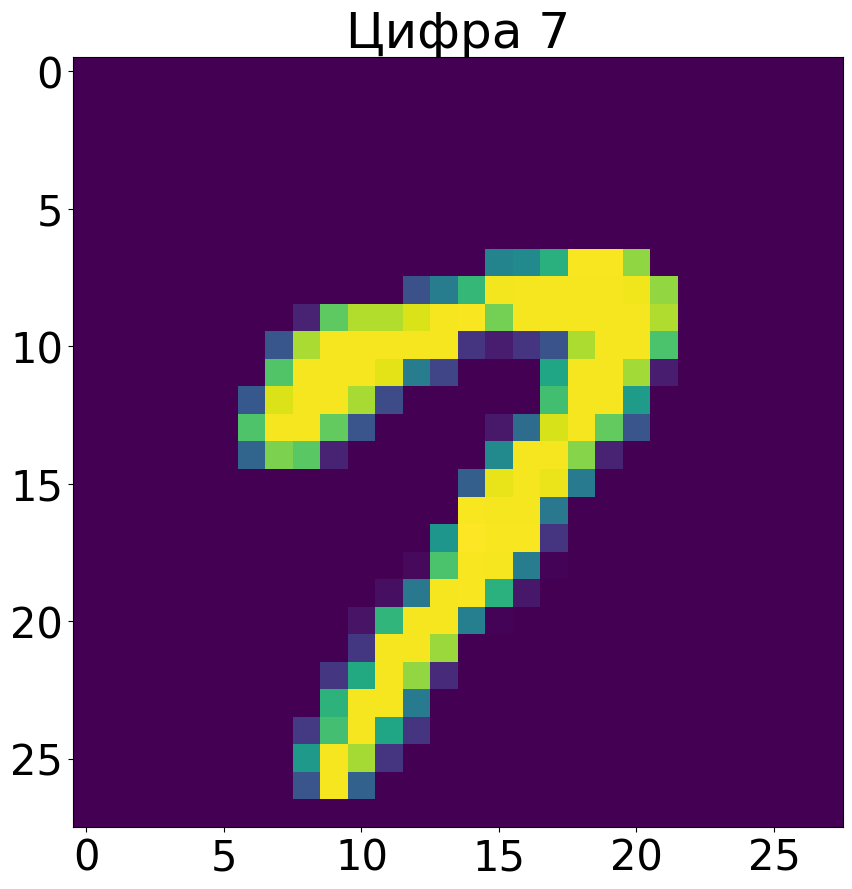

In [79]:
plt.figure(figsize=(10, 10))
plt.title(f'Цифра {mnist_train[15][1]}')
plt.imshow(mnist_train[15][0][0])

plt.show()

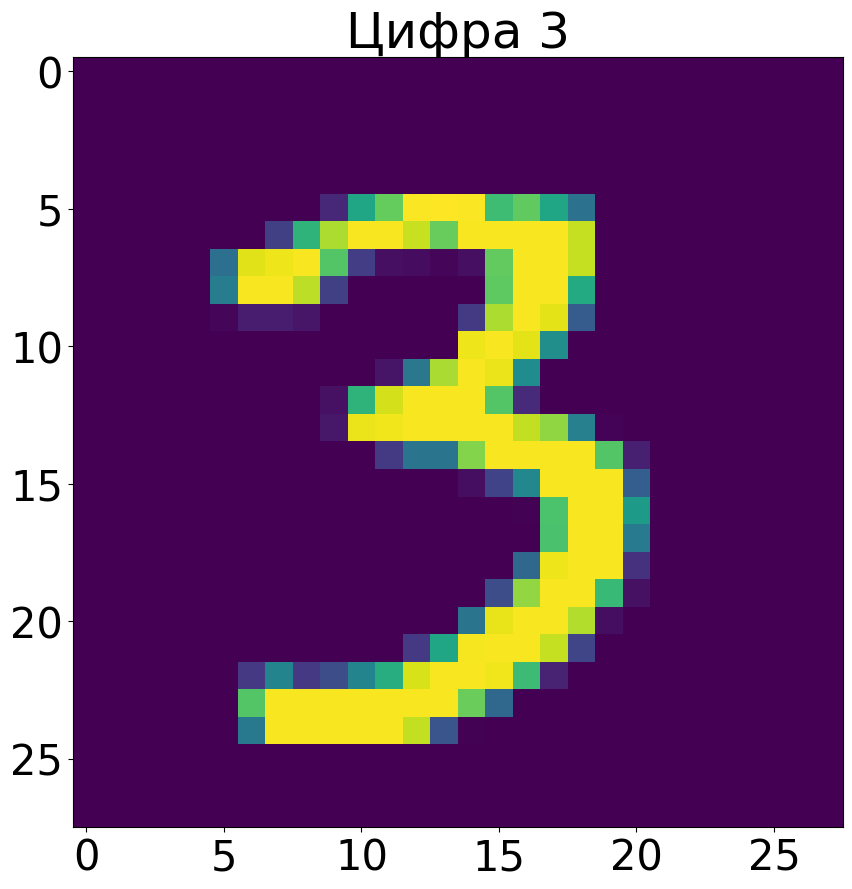

In [80]:
plt.figure(figsize=(10, 10))
plt.title(f'Цифра {mnist_train[10000][1]}')
plt.imshow(mnist_train[10000][0][0])

plt.show()

## Полносвязная нейронная сеть

Обучим полносвязную нейронную сеть на датасете MNIST.

In [81]:
def train(model: nn.Module) -> float:
    model.train()

    train_loss = 0

    for x, y in tqdm(train_loader, desc='Train'):
        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        train_loss += loss.item()

        loss.backward()

        optimizer.step()

    train_loss /= len(train_loader)
    
    return train_loss

In [82]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader):
    model.eval()

    total_loss = 0
    total = 0
    correct = 0

    for x, y in tqdm(loader, desc='Evaluation'):
        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        _, y_pred = torch.max(output, 1)
        total += y.size(0)
        correct += (y_pred == y).sum().item()

    total_loss /= len(loader)
    accuracy = correct / total

    return total_loss, accuracy

In [83]:
def plot_stats(
    train_loss,
    valid_loss,
    valid_accuracy,
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()
    plt.grid()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' valid accuracy')

    plt.plot(valid_accuracy)
    plt.grid()

    plt.show()

In [84]:
first_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 500),
    nn.ReLU(),
    nn.Linear(500, 200),
    nn.ReLU(),
    nn.Linear(200, 10)
)

optimizer = torch.optim.Adam(first_model.parameters(), lr=1e-3)

loss_fn = nn.CrossEntropyLoss()

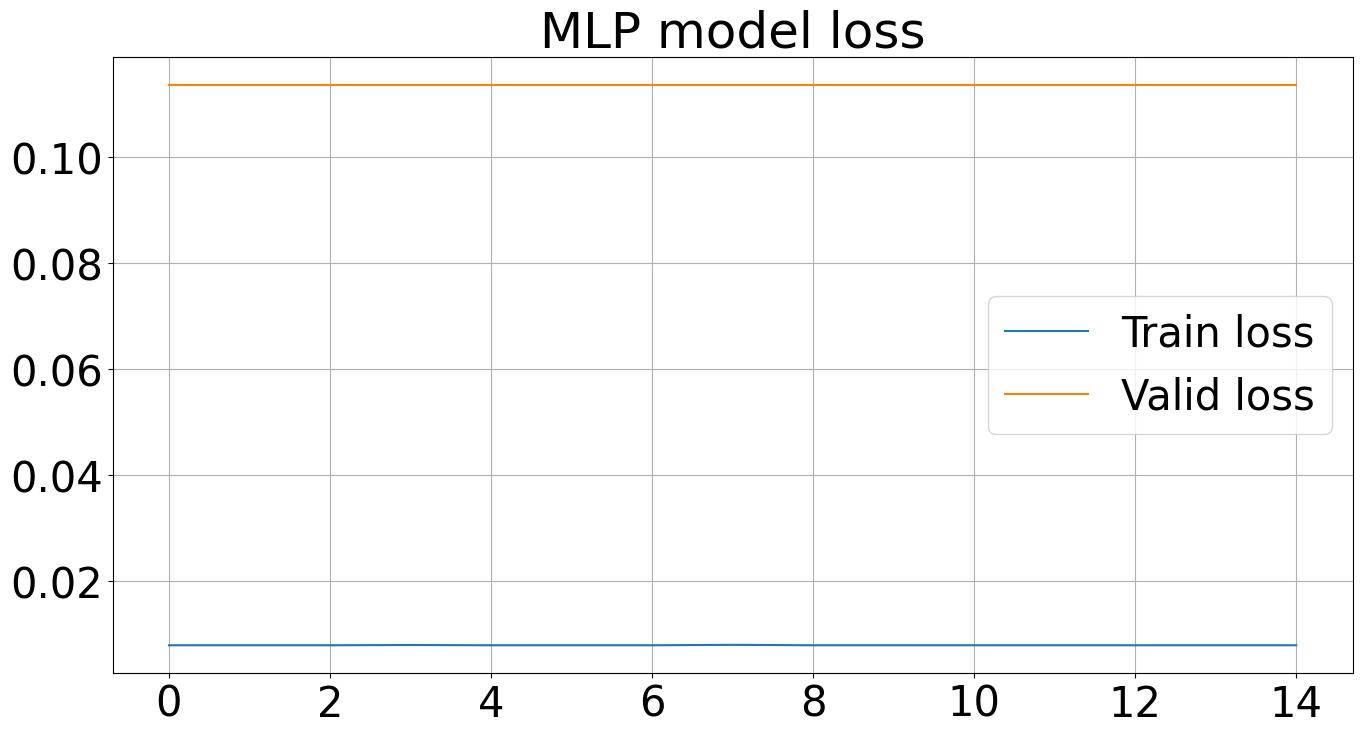

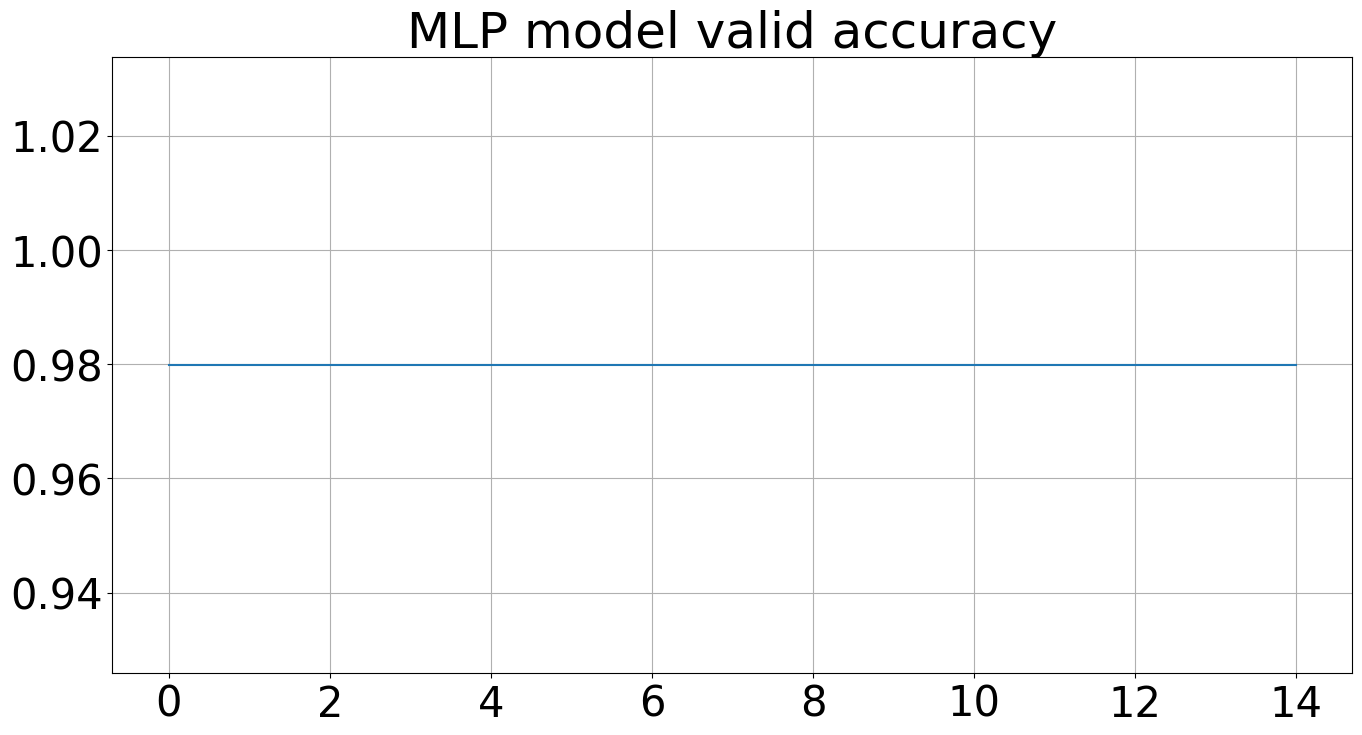

Evaluation: 100%|██████████████████████| 157/157 [00:00<00:00, 261.16it/s]

Total training and evaluation time 43.05833


In [103]:
num_epochs = 15

train_loss_history, valid_loss_history = [], []
valid_accuracy_history = []

start = perf_counter()

for epoch in range(num_epochs):
    valid_loss, valid_accuracy = evaluate(first_model, valid_loader)
    
    train_loss = train(first_model)

    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_accuracy_history.append(valid_accuracy)

    clear_output()

    plot_stats(train_loss_history, valid_loss_history, valid_accuracy_history, 'MLP model')
    

valid_loss, valid_accuracy = evaluate(first_model, valid_loader)
    
print(f'Total training and evaluation time {perf_counter() - start:.5f}')

In [104]:
valid_accuracy

0.9798

## Сверточная сеть

In [94]:
second_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5), #24*24
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2), #12*12

    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=5), # 8*8
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),  # 4*4
    
    nn.Flatten(),
    nn.Linear(4 * 4 * 16, 256),
    nn.LeakyReLU(),
    nn.Linear(256, 10)
)


x = torch.rand((1, 1, 28, 28))
print(x.shape)
print(second_model(x).shape)

torch.Size([1, 1, 28, 28])
torch.Size([1, 10])


In [ ]:
c_in * c_out * k1 * k2

In [95]:
16 * 5 ** 2 + 16 ** 2 * 5 ** 2

6800

In [96]:
4 * 4 * 16 * 256 + 256 * 10

68096

In [99]:
second_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5), #28*28
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2), #14*14

    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=5),
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(4 * 4 * 16, 256),
    nn.LeakyReLU(),
    nn.Linear(256, 10)
)

optimizer = torch.optim.Adam(second_model.parameters(), lr=7e-4)

loss_fn = nn.CrossEntropyLoss()

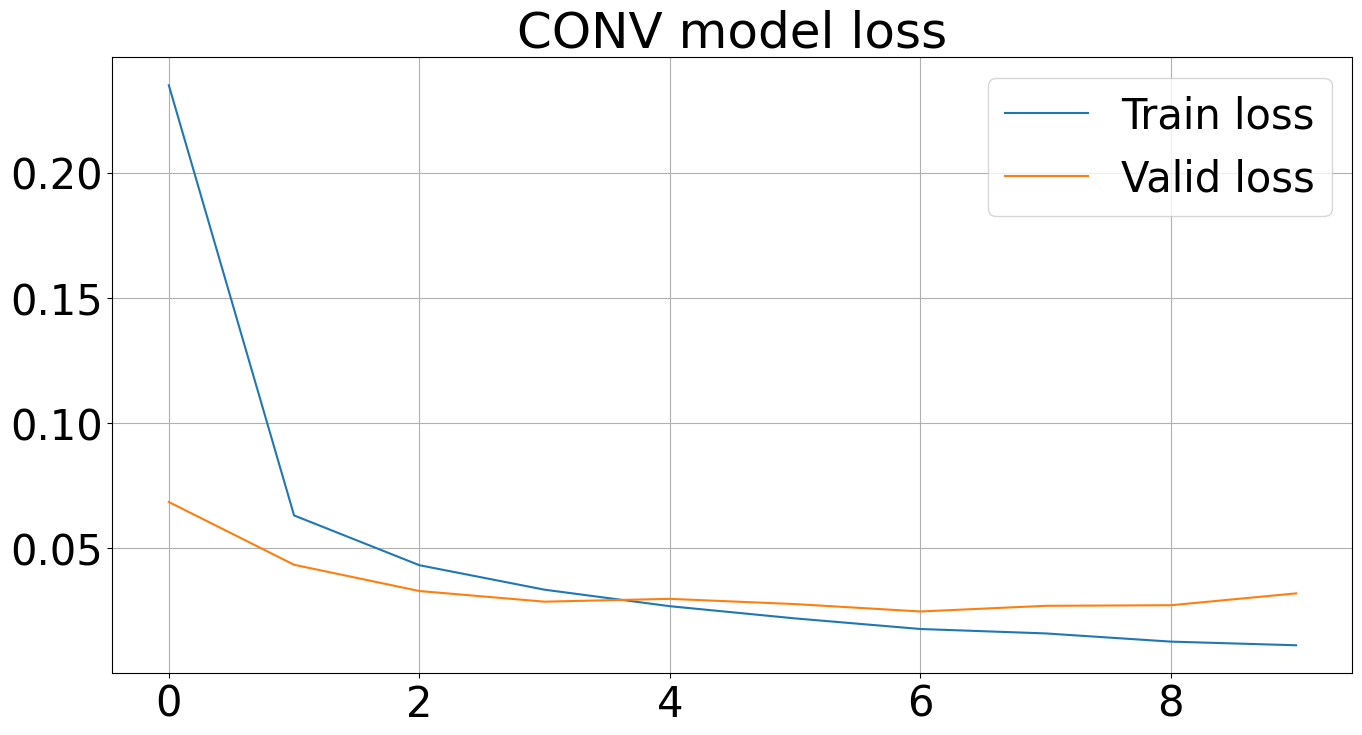

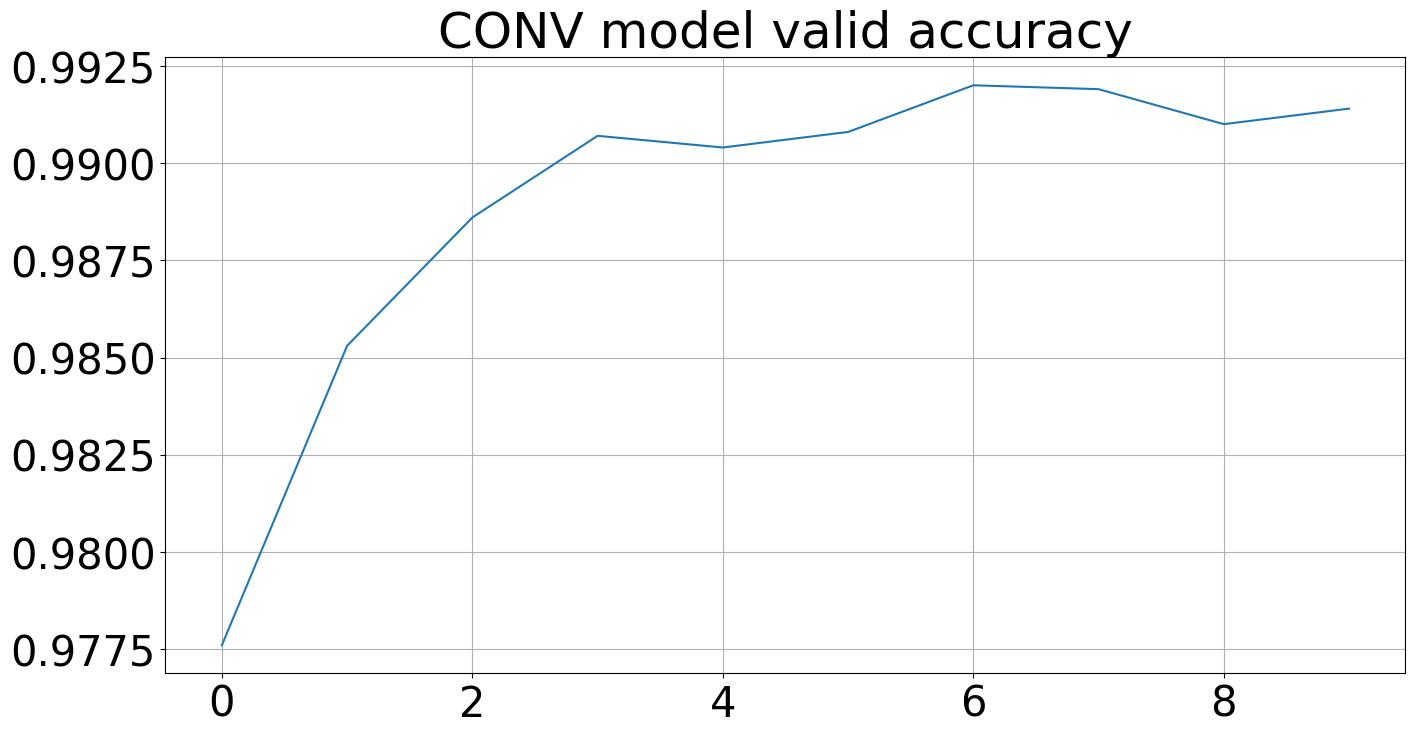

Total training and evaluation time 41.85088


In [100]:
num_epochs = 10

train_loss_history, valid_loss_history = [], []
valid_accuracy_history = []

start = perf_counter()

for epoch in range(num_epochs):
    train_loss = train(second_model)

    valid_loss, valid_accuracy = evaluate(second_model, valid_loader)

    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_accuracy_history.append(valid_accuracy)

    clear_output()

    plot_stats(train_loss_history, valid_loss_history, valid_accuracy_history, 'CONV model')

print(f'Total training and evaluation time {perf_counter() - start:.5f}')

In [102]:
valid_accuracy_history[-1]

0.9914

In [106]:
second_model.eval()

with torch.no_grad():
    for img, cls in valid_loader:
        print("predicted", torch.argmax(second_model(img)[:20], dim=1))
        print("true     ", cls[:20])

predicted tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4])
true      tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4])
predicted tensor([7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7])
true      tensor([7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7])
predicted tensor([8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2])
true      tensor([8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2])
predicted tensor([0, 9, 0, 3, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5])
true      tensor([0, 9, 0, 3, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5])
predicted tensor([2, 8, 2, 6, 8, 5, 7, 7, 9, 1, 0, 1, 8, 0, 3, 0, 1, 9, 9, 4])
true      tensor([2, 8, 2, 6, 8, 5, 7, 7, 9, 1, 8, 1, 8, 0, 3, 0, 1, 9, 9, 4])
predicted tensor([9, 2, 9, 3, 0, 4, 2, 0, 7, 1, 1, 2, 1, 5, 3, 3, 9, 7, 8, 6])
true      tensor([9, 2, 9, 3, 0, 4, 2, 0, 7, 1, 1, 2, 1, 5, 3, 3, 9, 7, 8, 6])
predicted tensor([6, 1, 6, 2, 1, 9, 2, 8, 6, 1, 9, 5

predicted tensor([2, 7, 7, 4, 0, 2, 4, 2, 1, 8, 9, 6, 1, 0, 5, 9, 6, 9, 8, 0])
true      tensor([2, 7, 7, 4, 0, 2, 4, 2, 1, 8, 9, 6, 1, 0, 5, 9, 6, 9, 8, 0])
predicted tensor([8, 3, 1, 5, 8, 2, 7, 4, 2, 1, 5, 4, 5, 5, 8, 6, 4, 4, 4, 1])
true      tensor([8, 3, 1, 5, 8, 2, 7, 4, 2, 1, 5, 4, 5, 5, 8, 6, 4, 4, 4, 1])
predicted tensor([3, 0, 2, 0, 1, 0, 1, 0, 4, 0, 1, 0, 4, 7, 9, 6, 2, 6, 2, 2])
true      tensor([3, 0, 2, 0, 1, 0, 1, 0, 4, 0, 1, 0, 4, 7, 9, 6, 2, 6, 2, 2])
predicted tensor([4, 7, 1, 9, 1, 7, 1, 4, 0, 0, 4, 1, 7, 5, 7, 1, 3, 3, 3, 1])
true      tensor([4, 7, 1, 9, 1, 7, 1, 4, 0, 0, 4, 1, 7, 5, 7, 1, 3, 3, 3, 1])
predicted tensor([8, 9, 6, 8, 8, 2, 3, 6, 1, 2, 9, 8, 9, 5, 2, 6, 2, 4, 8, 4])
true      tensor([8, 9, 6, 8, 8, 2, 3, 6, 1, 2, 9, 8, 9, 5, 2, 6, 2, 4, 8, 4])
predicted tensor([4, 6, 1, 0, 4, 5, 3, 9, 4, 2, 5, 5, 0, 1, 3, 2, 9, 1, 6, 0])
true      tensor([4, 6, 1, 0, 4, 5, 3, 9, 4, 2, 0, 5, 0, 1, 3, 2, 9, 1, 6, 0])
predicted tensor([3, 0, 1, 2, 3, 4, 5, 6, 7, 0, 1, 2

На семинаре был вопрос про то, можно ли заменить пулинг сверткой.
Ответ: можно, но не всегда нужно. Пулинг это операция (если maxpool то еще и нелинейная), в которой ничего не учится, но она отлично помогает уменьшить размер картинки и доказала свою эффективность во многих нейронках. Свертки - более сложные и ресурсозатратные слои с обучаемыми весами.

Попробуем  
1) заменить пулинги слоем свертка + активация (чтобы смоделировать нелинейность) и также просто расширим в сети число пара

In [115]:
second_model_replaced_pool_with_conv_lrelu = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5), #28*28
    nn.LeakyReLU(),
    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=2, stride=2, padding=0),
    nn.LeakyReLU(),

    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=5),
    nn.LeakyReLU(),
    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=2, stride=2, padding=0),
    nn.LeakyReLU(),

    nn.Flatten(),
    nn.Linear(4 * 4 * 16, 256),
    nn.LeakyReLU(),
    nn.Linear(256, 10)
)

optimizer = torch.optim.Adam(second_model_replaced_pool_with_conv_lrelu.parameters(), lr=7e-4)

loss_fn = nn.CrossEntropyLoss()

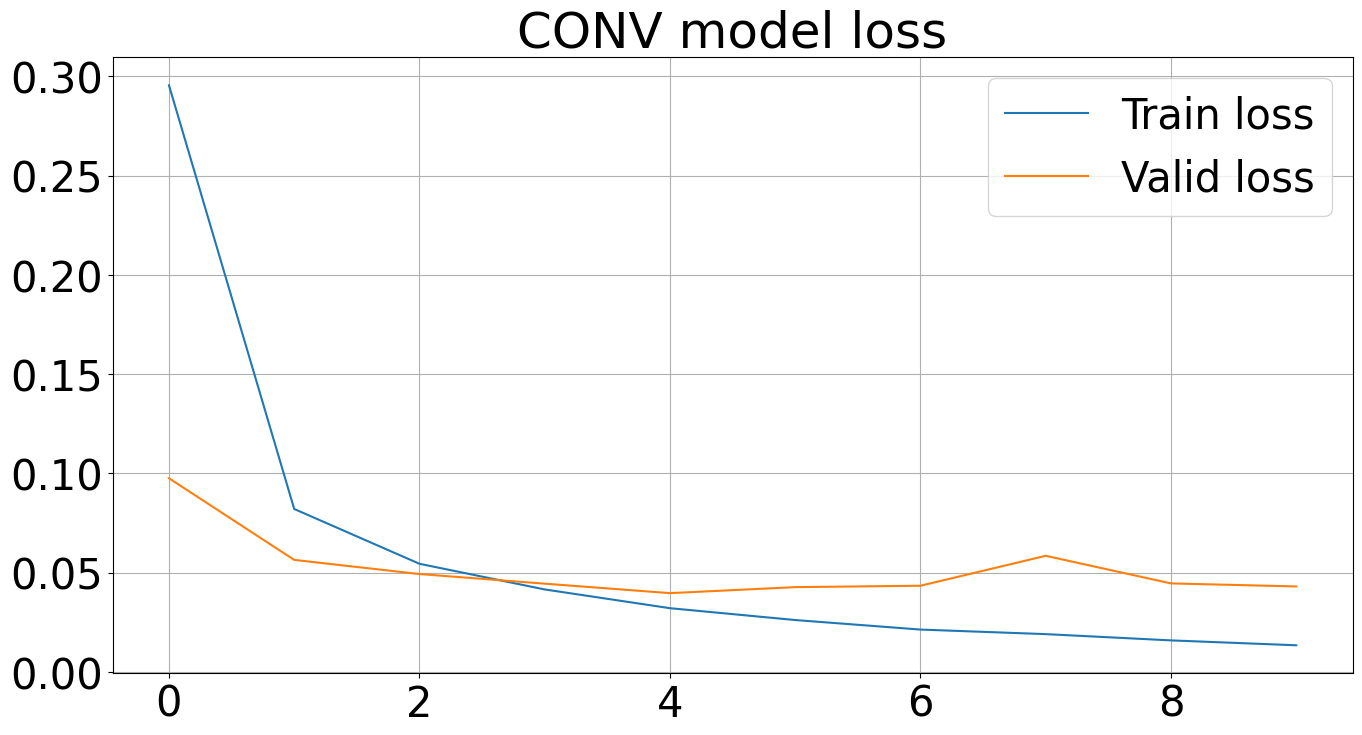

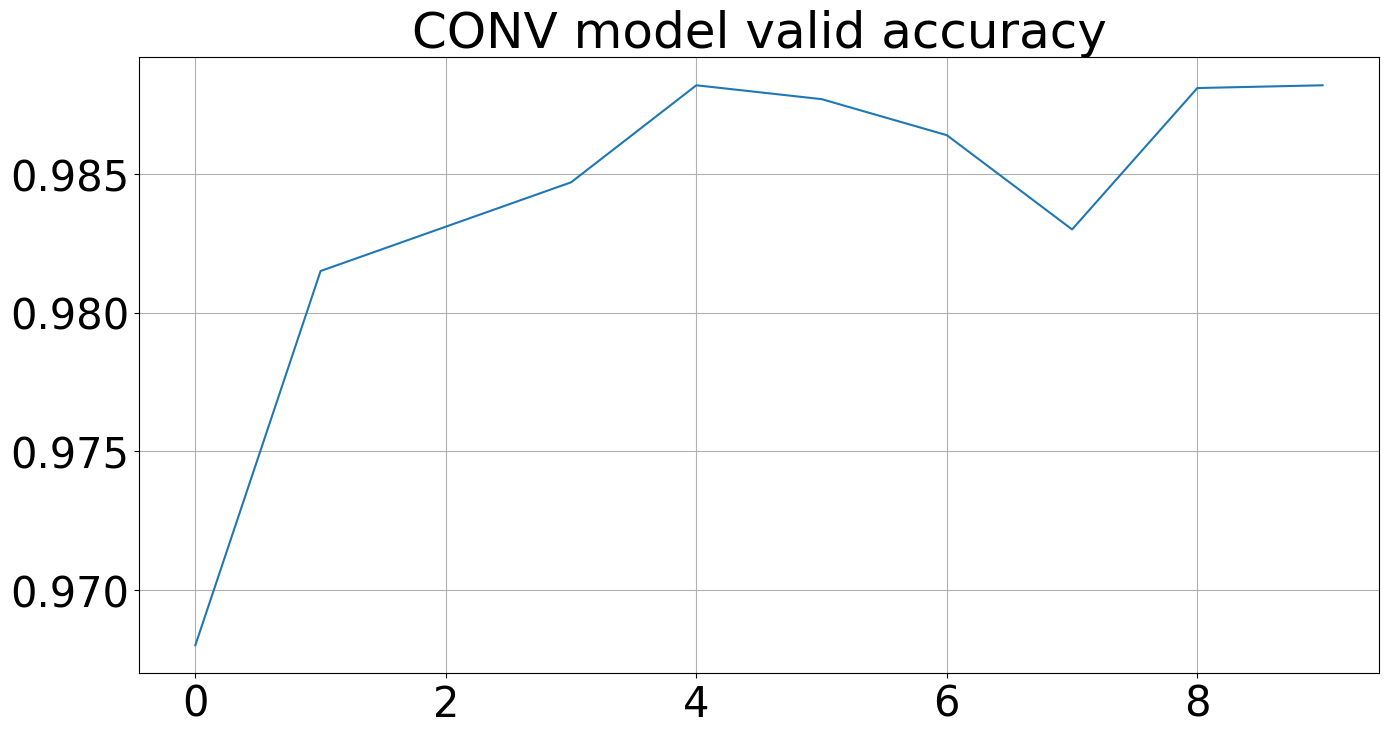

Total training and evaluation time 44.97998


In [116]:
num_epochs = 10

train_loss_history, valid_loss_history = [], []
valid_accuracy_history = []

start = perf_counter()

for epoch in range(num_epochs):
    train_loss = train(second_model_replaced_pool_with_conv_lrelu)

    valid_loss, valid_accuracy = evaluate(second_model_replaced_pool_with_conv_lrelu, valid_loader)

    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_accuracy_history.append(valid_accuracy)

    clear_output()

    plot_stats(train_loss_history, valid_loss_history, valid_accuracy_history, 'CONV model')

print(f'Total training and evaluation time {perf_counter() - start:.5f}')

In [117]:
valid_accuracy

0.9882

2) просто удалим пулинги, а ядро в предыдущей перед ним свертке увеличим в 2 раза и добавим страйд 2

In [112]:
second_model_del_maxpool = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=2), #28*28
    nn.LeakyReLU(),
    # nn.MaxPool2d(kernel_size=2), #14*14

    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=5, stride=2),
    nn.LeakyReLU(),
    # nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(4 * 4 * 16, 256),
    nn.LeakyReLU(),
    nn.Linear(256, 10)
)

optimizer = torch.optim.Adam(second_model_del_maxpool.parameters(), lr=7e-4)

loss_fn = nn.CrossEntropyLoss()

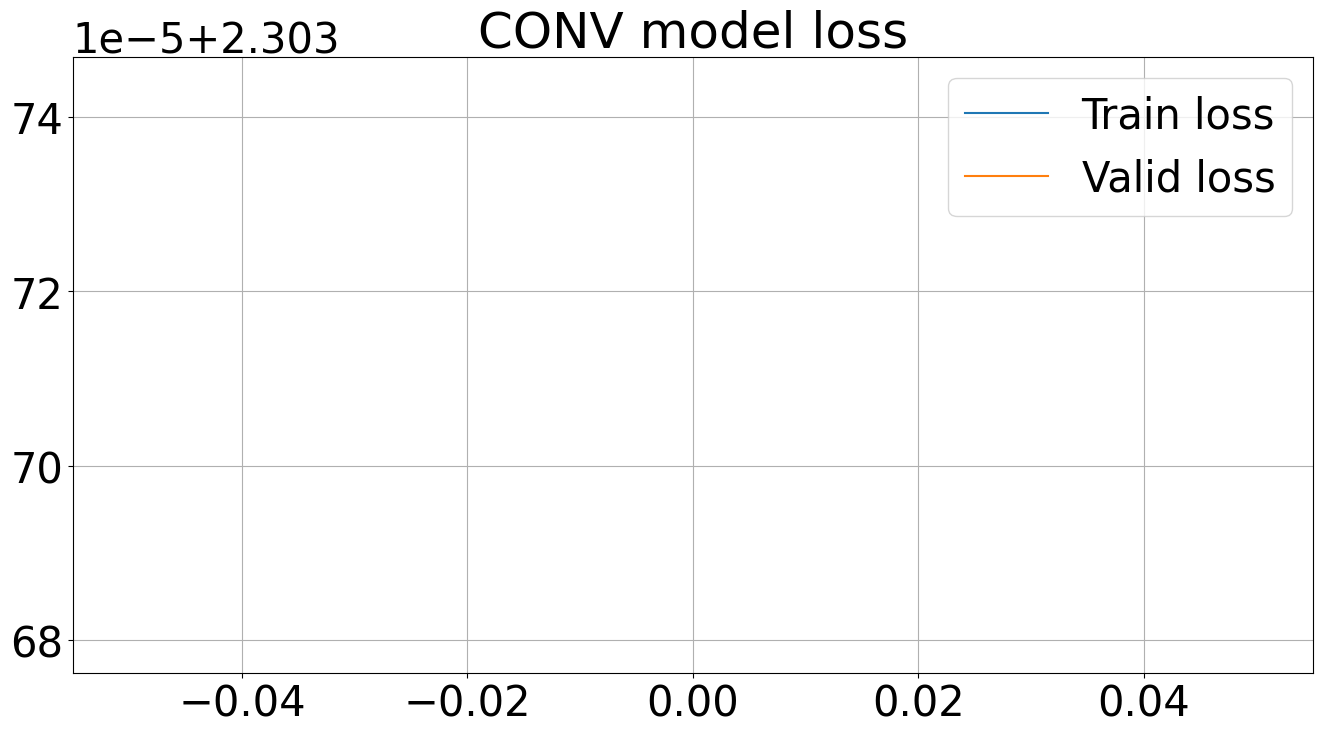

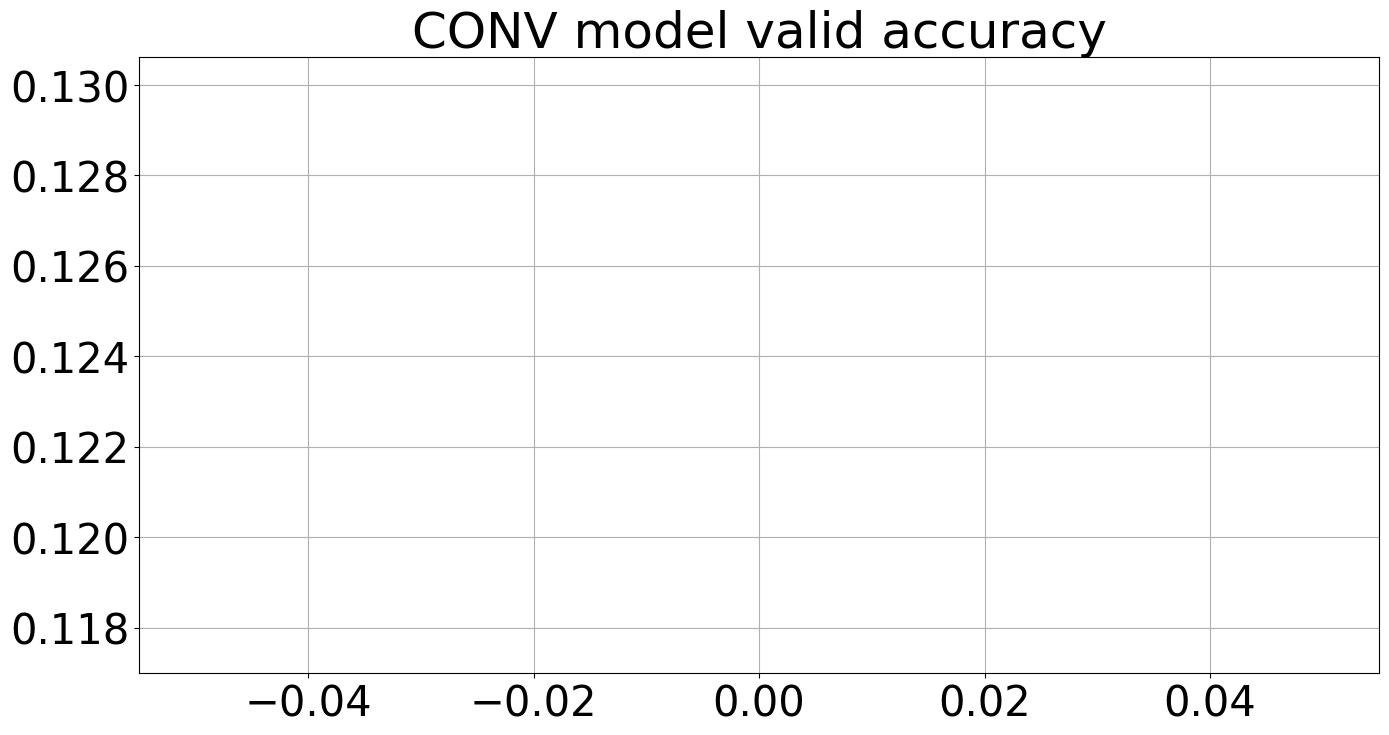

Train:  79%|█████████████████████▎     | 742/938 [00:01<00:00, 394.11it/s]


KeyboardInterrupt: 

In [118]:
num_epochs = 10

train_loss_history, valid_loss_history = [], []
valid_accuracy_history = []

start = perf_counter()

for epoch in range(num_epochs):
    train_loss = train(second_model_del_maxpool)

    valid_loss, valid_accuracy = evaluate(second_model_del_maxpool, valid_loader)

    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_accuracy_history.append(valid_accuracy)

    clear_output()

    plot_stats(train_loss_history, valid_loss_history, valid_accuracy_history, 'CONV model')

print(f'Total training and evaluation time {perf_counter() - start:.5f}')

In [ ]:
valid_accuracy

3. Сделаем полносверточную модель

In [120]:
second_model_replaced_pool = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=10, padding=2, stride=2), #28*28
    nn.LeakyReLU(),

    nn.Conv2d(in_channels=16, out_channels=16, kernel_size=10, padding=2, stride=2),
    nn.LeakyReLU(),
    nn.Conv2d(in_channels=16, out_channels=10, kernel_size=2, stride=2, padding=0),
    nn.AvgPool2d(kernel_size=2),
    nn.Flatten()
)
# x = torch.rand((1, 1, 28, 28))
# second_model_replaced_pool(x).shape

optimizer = torch.optim.Adam(second_model_replaced_pool.parameters(), lr=7e-4)

loss_fn = nn.CrossEntropyLoss()

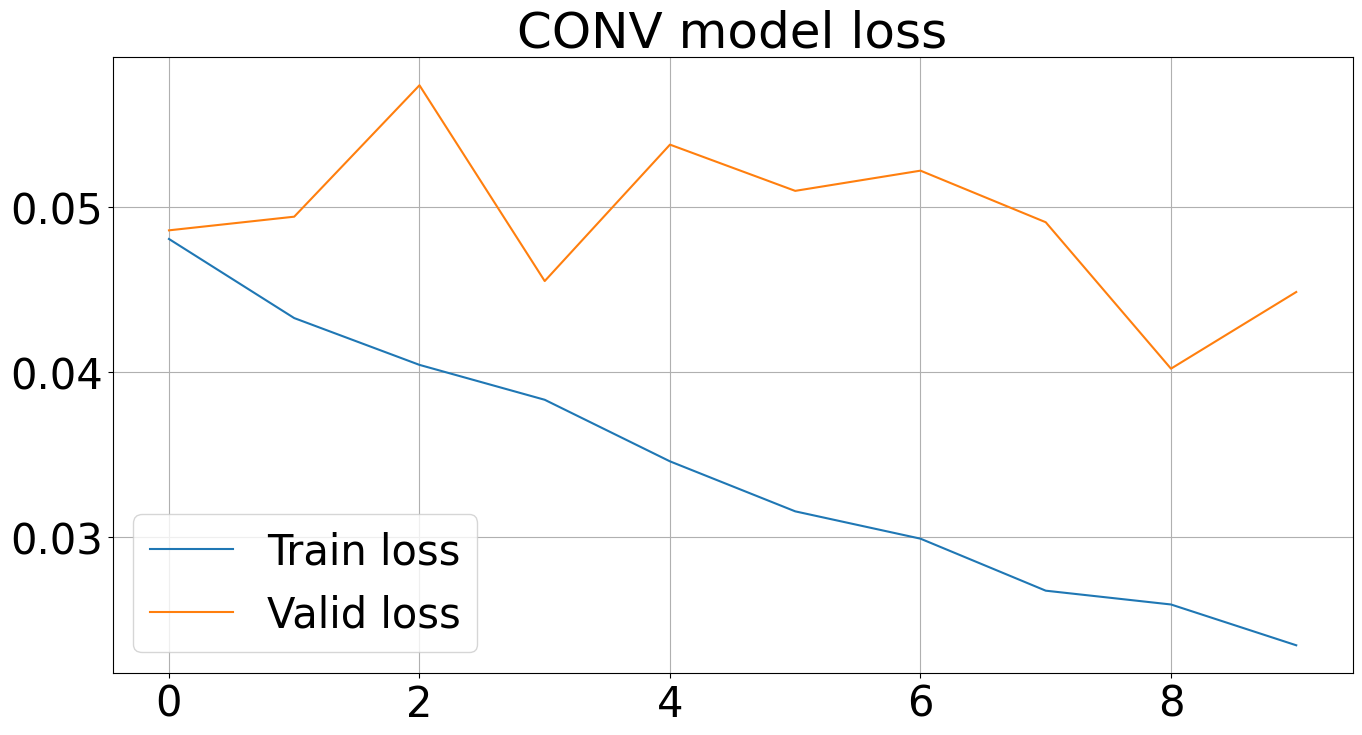

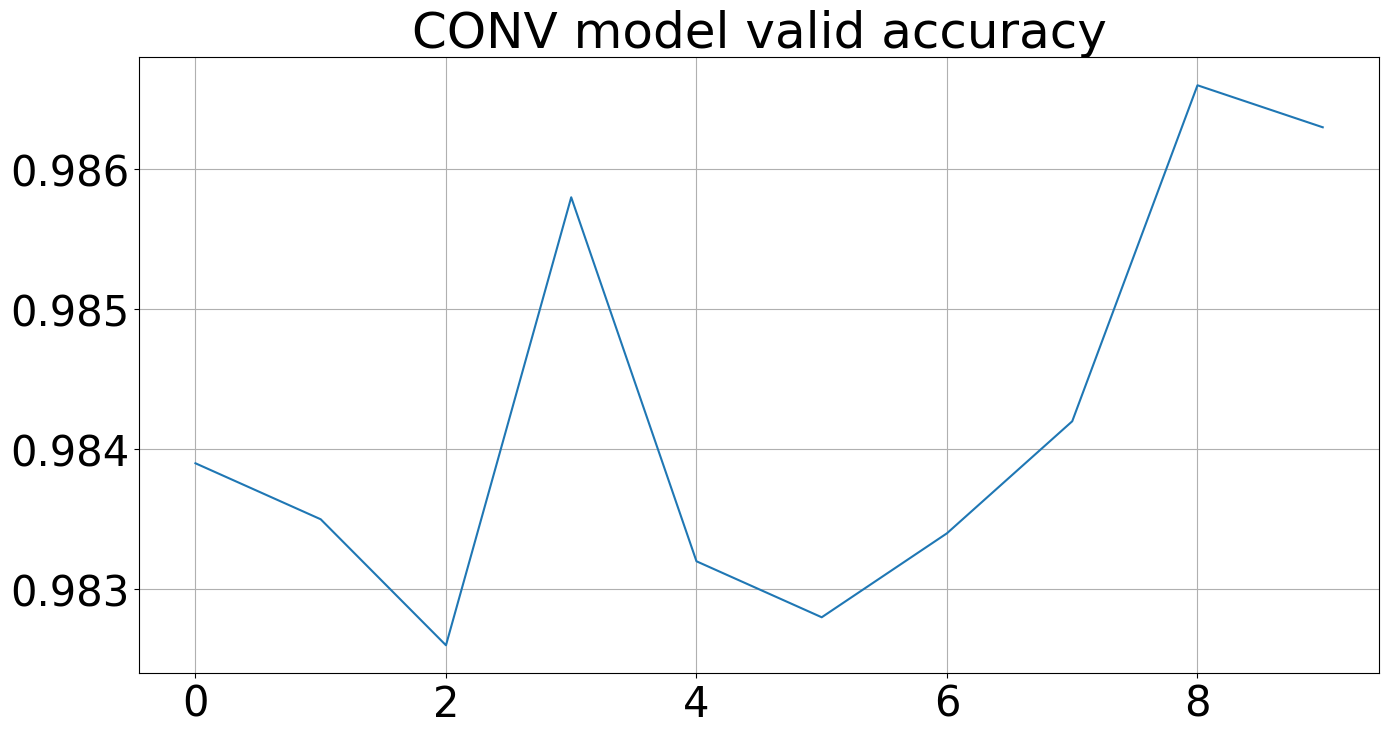

Total training and evaluation time 43.10741


In [123]:
num_epochs = 10

train_loss_history, valid_loss_history = [], []
valid_accuracy_history = []

start = perf_counter()

for epoch in range(num_epochs):
    train_loss = train(second_model_replaced_pool)

    valid_loss, valid_accuracy = evaluate(second_model_replaced_pool, valid_loader)

    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_accuracy_history.append(valid_accuracy)

    clear_output()

    plot_stats(train_loss_history, valid_loss_history, valid_accuracy_history, 'CONV model')

print(f'Total training and evaluation time {perf_counter() - start:.5f}')

In [124]:
valid_accuracy

0.9863

Как видим, полносверточная модель дает очень близкое качество, при этом имеет в 10 раз меньше весов!